In [12]:
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

In [2]:
with open('../datasets/mod_05_topic_10_various_data.pkl', 'rb') as fl:
    datasets = pickle.load(fl)
datasets.keys()

dict_keys(['autos', 'concrete', 'customer', 'accidents'])

In [3]:
df = datasets['concrete']
df

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31
...,...,...,...,...,...,...,...,...
422,528.0,0.0,0.0,185.0,6.9,920.0,720.0,56.83
423,531.3,0.0,0.0,141.8,28.2,852.1,893.7,59.20
424,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,79.99
425,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,61.89


In [5]:
df['Components'] = df.gt(0).sum(axis=1)
df

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46,6
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23,6
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02,6
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19,6
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31,8
...,...,...,...,...,...,...,...,...,...
422,528.0,0.0,0.0,185.0,6.9,920.0,720.0,56.83,6
423,531.3,0.0,0.0,141.8,28.2,852.1,893.7,59.20,6
424,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,79.99,6
425,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,61.89,6


In [9]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-1.57141664,  0.7856755 , -0.93768524, ...,  2.42603905,
        -0.87083257, -0.78362084],
       [-1.51048402,  0.8927699 , -0.93768524, ...,  1.15508554,
        -0.62851424, -0.78362084],
       [-1.43601081,  1.01353592, -0.93768524, ...,  1.74136409,
        -0.51346124, -0.78362084],
       ...,
       [ 2.66485159, -0.95745664, -0.93768524, ..., -1.20916131,
         2.63410599, -0.78362084],
       [ 2.66485159, -0.95745664, -0.93768524, ..., -1.20916131,
         1.47072092, -0.78362084],
       [ 2.66485159, -0.95745664, -0.93768524, ..., -2.07012982,
         2.26002306, -1.76200124]])

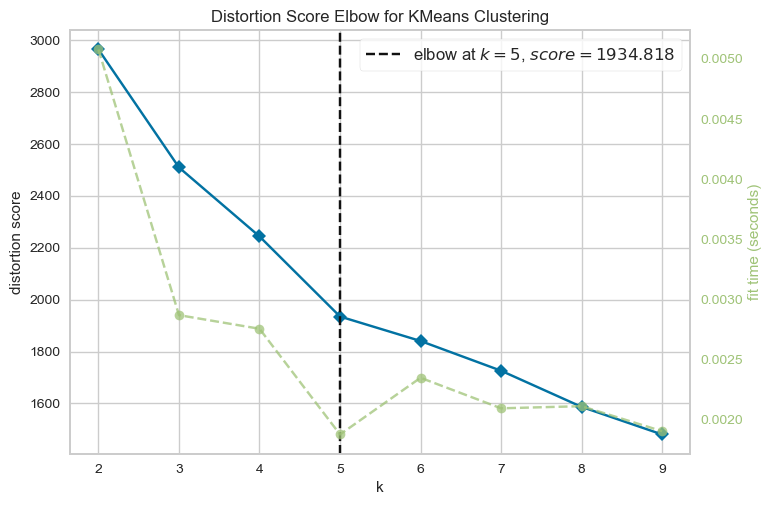

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(df_scaled)
visualizer.show()

In [20]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)
df

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Cluster
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46,6,1
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23,6,1
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02,6,1
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19,6,1
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31,8,2
...,...,...,...,...,...,...,...,...,...,...
422,528.0,0.0,0.0,185.0,6.9,920.0,720.0,56.83,6,3
423,531.3,0.0,0.0,141.8,28.2,852.1,893.7,59.20,6,3
424,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,79.99,6,3
425,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,61.89,6,3


In [23]:
cluster_report = df.groupby('Cluster').median()

In [22]:
cluster_report['Count'] = df['Cluster'].value_counts()
cluster_report

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Count
Cluster,,,,,,,,,,
0,203.35,0.00,125.15,170.20,9.65,1004.7,795.55,39.88,7.0,84
1,188.10,183.00,0.00,185.75,3.00,973.0,754.65,37.43,7.0,90
2,181.00,119.25,113.10,193.90,8.55,879.8,741.20,32.40,8.0,112
3,387.00,102.05,0.00,162.00,9.80,918.5,786.25,61.66,7.0,60
4,339.00,0.00,0.00,189.00,0.00,1040.0,775.00,33.70,5.0,81
